In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
df = pd.read_csv("Spotify_Dataset_V3.csv", delimiter=';')
df_us = df[df['Nationality'] == 'United States']
df_us.head(5)

,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Valence,# of Artist,Artist (Ind.),# of Nationality,Nationality,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL
8,6,Flowers,Miley Cyrus,29/05/2023,0.707,0.681,-4325.0,0.067,0.063,0.000,0.646,Artist 1,Miley Cyrus,Nationality 1,United States,Anglo-America,195,195.0,4DHcnVTT87F0zZhRPYmZ3B,https://open.spotify.com/track/4DHcnVTT87F0zZh...
9,7,Daylight,David Kushner,29/05/2023,0.508,0.430,-9475.0,0.034,0.830,0.000,0.324,Artist 1,David Kushner,Nationality 1,United States,Anglo-America,194,194.0,1odExI7RdWc4BT515LTAwj,https://open.spotify.com/track/1odExI7RdWc4BT5...
10,8,Kill Bill,SZA,29/05/2023,0.644,0.735,-5747.0,0.039,0.052,0.144,0.418,Artist 1,SZA,Nationality 1,United States,Anglo-America,193,193.0,1Qrg8KqiBpW07V7PNxwwwL,https://open.spotify.com/track/1Qrg8KqiBpW07V7...
17,13,Anti-Hero,Taylor Swift,29/05/2023,0.637,0.643,-6571.0,0.052,0.130,0.000,0.533,Artist 1,Taylor Swift,Nationality 1,United States,Anglo-America,188,188.0,0V3wPSX9ygBnCm8psDIegu,https://open.spotify.com/track/0V3wPSX9ygBnCm8...
19,14,Calm Down (with Selena Gomez),"Rema, Selena Gomez",29/05/2023,0.799,0.802,-5196.0,0.037,0.429,0.001,0.811,Artist 2,Selena Gomez,Nationality 2,United States,Anglo-America,187,93.5,1s7oOCT8vauUh01PbJD6ps,https://open.spotify.com/track/1s7oOCT8vauUh01...


In [4]:
# checking if there are any null / na values
df_us.isna().values.any()

np.False_

In [5]:
G = nx.Graph()
for artists in df_us['Artists'].dropna():
    artist_list = [a.strip() for a in artists.split(',')]
    for i in range(len(artist_list)):
        for j in range(i+1, len(artist_list)):
            G.add_edge(artist_list[i], artist_list[j])

In [6]:
# artists with the most collaborations (degree centrality)
degree = nx.degree_centrality(G)

# artists with the most influential connections (eigenvector centrality)
eigenvector = nx.eigenvector_centrality(G, max_iter=500)

# artists who connect different communities (betweenness centrality)
betweenness = nx.betweenness_centrality(G)

In [7]:
centrality_df = pd.DataFrame({
    "artist": degree.keys(),
    "degree centrality": degree.values(),
    "betweenness centrality" : betweenness.values(),
    "eigenvector centrality" : eigenvector.values()
})

top_artists = centrality_df.sort_values(by="eigenvector centrality", ascending=False).head(10)


print(top_artists)

            artist  degree centrality  betweenness centrality  \
38    Travis Scott           0.037175                0.030363   
122          Drake           0.029740                0.018700   
119      DJ Khaled           0.032218                0.023297   
47          Future           0.037175                0.056306   
4        21 Savage           0.027261                0.015851   
39      Young Thug           0.034696                0.032678   
98           Quavo           0.024783                0.020281   
2     Metro Boomin           0.021066                0.004982   
118     Kanye West           0.034696                0.054929   
390  Ty Dolla $ign           0.028501                0.028209   

     eigenvector centrality  
38                 0.285032  
122                0.247827  
119                0.243258  
47                 0.235685  
4                  0.215917  
39                 0.188574  
98                 0.181327  
2                  0.178377  
118           

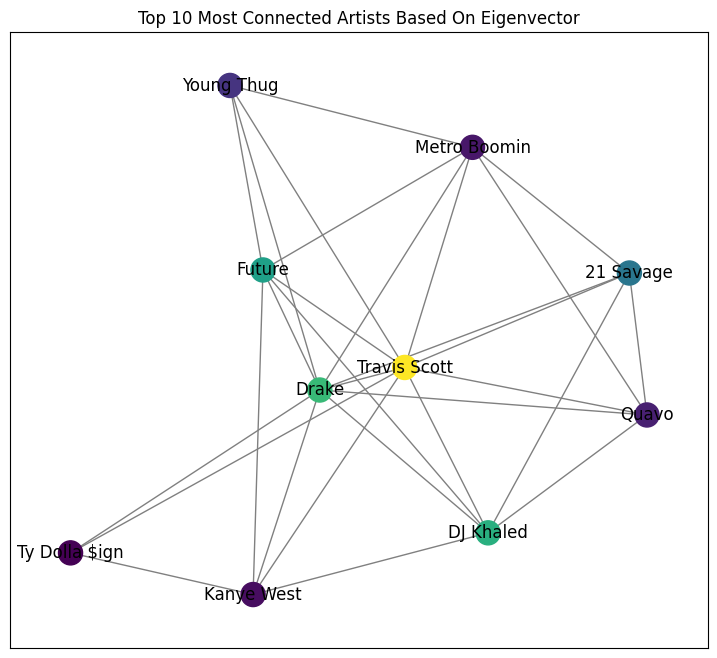

In [8]:
top_nodes = sorted(eigenvector, key=eigenvector.get, reverse=True)[:10]
subgraph = G.subgraph(top_nodes)

plt.figure(figsize=(9, 8))
pos = nx.spring_layout(subgraph, k=0.5, seed=42)
node_color = [eigenvector[node] for node in subgraph.nodes()]

nx.draw_networkx(subgraph, pos,with_labels=True,node_color=node_color,  edge_color="gray")
plt.title("Top 10 Most Connected Artists Based On Eigenvector")
plt.show()